# 1999 Czech Financial Dataset — Classification Usage Notebook

This notebook demonstrates a clean, leakage-aware workflow for using the **1999 Czech Financial / PKDD'99 / Berka banking dataset** for loan-risk classification.

The goal is to build **one row per loan**, predict the loan `status`, and use only information that would have been available **before the loan started**.

## What this notebook covers

1. Dataset-path detection on Kaggle
2. Loading and normalizing all 8 relational tables
3. Building a loan-level classification matrix
4. Basic data-quality checks
5. Temporal train/test split
6. Model benchmarking
7. Threshold tuning for bad-loan detection
8. Feature importance
9. Optional leakage/robustness ablation
10. Exporting processed features and trained model


In [1]:
import sys
from pathlib import Path

# Find project root by walking upward until pyproject.toml is found
PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Import root added:", PROJECT_ROOT)

Project root: /Users/wiktorsmura/studies/sem4/machine-learning/ml-case-study
Import root added: /Users/wiktorsmura/studies/sem4/machine-learning/ml-case-study


## 1. Imports and environment check

This cell imports the module and prints package versions. On Kaggle, make sure you have added the dataset from:

`/kaggle/input/1999-czech-financial-dataset`

The auto-detection function below also tries to find the dataset if Kaggle used a slightly different folder name.


In [2]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display

from src.preprocessing.czech_financial_preprocessing_pipeline import (
    CzechFinancialConfig,
    build_classification_dataset,
    evaluate_binary_classifier,
    get_feature_names,
    load_and_normalize_tables,
    make_model_pipeline,
    make_target,
    quick_data_quality_report,
    temporal_train_test_split,
    threshold_table,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
warnings.simplefilter("default")

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("working directory:", Path.cwd())

Python: 3.12.9
pandas: 3.0.3
numpy: 2.4.5
scikit-learn: 1.8.0
working directory: /Users/wiktorsmura/studies/sem4/machine-learning/ml-case-study/src/notebooks


## 2. Locate the dataset folder

The pipeline can read common variants of the dataset files, including CSV, semicolon-delimited files, original `.asc` files, and files with names like `fin_loan.tsv`.

If auto-detection fails, manually set `DATA_DIR` to the folder that contains the dataset tables.


In [3]:
DATA_DIR = Path("../../data/raw")
assert DATA_DIR.exists()

## 3. Load and inspect the raw relational tables

The dataset is relational. The important point is that transactions, clients, cards, orders, and district data need to be aggregated or joined carefully to the `loan` table.


In [4]:
tables = load_and_normalize_tables(DATA_DIR)

summary = []
for name, df in tables.items():
    summary.append(
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "missing_cells": int(df.isna().sum().sum()),
        }
    )

summary_df = pd.DataFrame(summary).sort_values("table")
display(summary_df)

for name in sorted(tables):
    print(f"\n{name.upper()}  shape={tables[name].shape}")
    display(tables[name].head(3))

,table,rows,columns,missing_cells
0,account,4500,4,0
7,card,892,4,0
1,client,5369,5,0
2,disp,5369,4,0
3,district,77,16,2
4,loan,682,7,0
5,order,6471,6,1379
6,trans,1056320,10,2262171



ACCOUNT  shape=(4500, 4)


,account_id,district_id,frequency,account_date
0,576,55,POPLATEK MESICNE,1993-01-01
1,3818,74,POPLATEK MESICNE,1993-01-01
2,704,55,POPLATEK MESICNE,1993-01-01



CARD  shape=(892, 4)


,card_id,disp_id,card_type,issued_date
0,1005,9285,C,1993-11-07
1,104,588,C,1994-01-19
2,747,4915,C,1994-02-05


...

,loan_id,account_id,loan_date,amount,duration,payments,status
0,5314,1787,1993-07-05,96396,12,8033.0,B
1,5316,1801,1993-07-11,165960,36,4610.0,A
2,6863,9188,1993-07-28,127080,60,2118.0,A



ORDER  shape=(6471, 6)


,order_id,account_id,bank_to,account_to,amount,category
0,29401,1,YZ,87144583,2452.0,HH
1,29402,2,ST,89597016,3372.7,LO
2,29403,2,QR,13943797,7266.0,HH



TRANS  shape=(1056320, 10)


,trans_id,account_id,trans_date,trans_type,operation,amount,balance,category,bank,account
0,695247,2378,1993-01-01,C,CIC,700.0,700.0,NaN,<NA>,NaN
1,171812,576,1993-01-01,C,CIC,900.0,900.0,NaN,<NA>,NaN
2,207264,704,1993-01-01,C,CIC,1000.0,1000.0,NaN,<NA>,NaN


## 4. Understand the classification target

The usual target is `loan.status`.

Typical interpretation:

- `A`: finished contract, no problems
- `B`: finished contract, loan not paid
- `C`: running contract, OK so far
- `D`: running contract, client in debt

This notebook uses `target_mode="all_binary"` by default:

- `0`: good / no current problem (`A` or `C`)
- `1`: bad / repayment problem (`B` or `D`)

For a stricter but smaller experiment, use `target_mode="finished_binary"`, which keeps only `A` and `B` loans.


In [5]:
loan_all_binary = make_target(tables["loan"], mode="all_binary")
loan_finished_binary = make_target(tables["loan"], mode="finished_binary")

print("All-binary target: A/C = 0, B/D = 1")
display(pd.crosstab(loan_all_binary["status"], loan_all_binary["target"], margins=True))

print("\nFinished-binary target: A = 0, B = 1")
display(pd.crosstab(loan_finished_binary["status"], loan_finished_binary["target"], margins=True))

print(
    "Loan-date range:",
    tables["loan"]["loan_date"].min(),
    "to",
    tables["loan"]["loan_date"].max(),
)

All-binary target: A/C = 0, B/D = 1


target,0,1,All
status,,,
A,203,0,203
B,0,31,31
C,403,0,403
D,0,45,45
All,606,76,682



Finished-binary target: A = 0, B = 1


target,0,1,All
status,,,
A,203,0,203
B,0,31,31
All,203,31,234


Loan-date range: 1993-07-05 00:00:00 to 1998-12-08 00:00:00


## 5. Build the loan-level classification matrix

This step creates one feature row per loan.

Important leakage controls:

- Transaction features are computed only from transactions before the loan date.
- Card features are computed only for cards issued before or on the loan date.
- Orders are optional because the classic order table has no timestamp. They are useful, but not perfectly time-auditable.

The configuration below is a strong default for experimentation.


In [6]:
config = CzechFinancialConfig(
    data_dir=DATA_DIR,
    target_mode="all_binary",  # use "finished_binary" for A vs B only
    transaction_windows_days=(30, 90, 180, 365),
    include_full_history=True,
    # include_orders=True,  # run an ablation later with False
    include_orders=False,  # run an ablation later with False
    include_cards=True,
    include_district=True,
    include_owner_client=True,
    strict_pre_loan_transactions=True,  # trans_date < loan_date
    min_category_count=5,
    random_state=42,
)

X, y, meta = build_classification_dataset(config, tables=tables)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("metadata shape:", meta.shape)

print("\nMetadata preview:")
display(meta.head())

print("\nFeature preview:")
display(X.head())

X shape: (682, 96)
y shape: (682,)
metadata shape: (682, 9)

Metadata preview:


,loan_id,account_id,loan_date,status,target,amount,duration,payments,account_date
0,5314,1787,1993-07-05,B,1,96396,12,8033.0,1993-03-22
1,5316,1801,1993-07-11,A,0,165960,36,4610.0,1993-02-13
2,6863,9188,1993-07-28,A,0,127080,60,2118.0,1993-02-08
3,5325,1843,1993-08-03,A,0,105804,36,2939.0,1993-01-30
4,7240,11013,1993-09-06,A,0,274740,60,4579.0,1993-02-14



Feature preview:


,account_statement_frequency,loan_amount,loan_duration_months,account_age_days_at_loan,client_count,disponent_count,owner_age_years_at_loan,owner_gender,owner_same_as_account_district,account_district_region,account_district_average_salary,account_district_unemployment_rate96,account_district_ratio_urban,account_district_num_entrep_per1000,account_district_num_inhabitants_log1p,account_district_crime_rate96_per_1000,hist_tx_count,hist_active_days,hist_credit_amount_sum,hist_debit_amount_sum,hist_net_cashflow_sum,hist_household_payment_amount_sum,hist_insurance_payment_amount_sum,hist_balance_min,hist_balance_mean,hist_negative_balance_rate,hist_credit_tx_rate,hist_cash_withdrawal_rate,hist_cash_deposit_rate,hist_bank_transfer_rate,hist_days_since_last_tx,hist_history_span_days,hist_last_balance,hist_balance_change,hist_balance_change_per_day,tx_1_30d_tx_count,tx_1_30d_active_days,tx_1_30d_credit_amount_sum,tx_1_30d_debit_amount_sum,tx_1_30d_net_cashflow_sum,tx_1_30d_household_payment_amount_sum,tx_1_30d_insurance_payment_amount_sum,tx_1_30d_balance_min,tx_1_30d_balance_mean,tx_1_30d_negative_balance_rate,tx_1_30d_credit_tx_rate,tx_1_30d_cash_withdrawal_rate,tx_1_30d_cash_deposit_rate,tx_1_30d_bank_transfer_rate,tx_31_90d_tx_count,tx_31_90d_active_days,tx_31_90d_credit_amount_sum,tx_31_90d_debit_amount_sum,tx_31_90d_net_cashflow_sum,tx_31_90d_household_payment_amount_sum,tx_31_90d_insurance_payment_amount_sum,tx_31_90d_balance_min,tx_31_90d_balance_mean,tx_31_90d_negative_balance_rate,tx_31_90d_credit_tx_rate,tx_31_90d_cash_withdrawal_rate,tx_31_90d_cash_deposit_rate,tx_31_90d_bank_transfer_rate,tx_91_180d_tx_count,tx_91_180d_active_days,tx_91_180d_credit_amount_sum,tx_91_180d_debit_amount_sum,tx_91_180d_net_cashflow_sum,tx_91_180d_household_payment_amount_sum,tx_91_180d_insurance_payment_amount_sum,tx_91_180d_balance_min,tx_91_180d_balance_mean,tx_91_180d_negative_balance_rate,tx_91_180d_credit_tx_rate,tx_91_180d_cash_withdrawal_rate,tx_91_180d_cash_deposit_rate,tx_91_180d_bank_transfer_rate,tx_181_365d_tx_count,tx_181_365d_active_days,tx_181_365d_credit_amount_sum,tx_181_365d_debit_amount_sum,tx_181_365d_net_cashflow_sum,tx_181_365d_household_payment_amount_sum,tx_181_365d_insurance_payment_amount_sum,tx_181_365d_balance_min,tx_181_365d_balance_mean,tx_181_365d_negative_balance_rate,tx_181_365d_credit_tx_rate,tx_181_365d_cash_withdrawal_rate,tx_181_365d_cash_deposit_rate,tx_181_365d_bank_transfer_rate,card_count_before_loan,latest_card_type_before_loan,days_since_latest_card,tx_181_365d_has_activity,tx_31_90d_has_activity
0,POPLATEK TYDNE,96396,12,105,1,0,45.954825,F,1,west Bohemia,9650,3.67,81.8,100,11.459662,29.574315,4,4,20100.0,0.0,20100.0,0.0,0.0,1100.0,12250.000000,0.0,1.000000,0.000000,1.000000,0.000000,15,90,20100.0,19000.0,211.111111,1,1,3300.0,0.0,3300.0,0.0,0.0,20100.0,20100.000000,0.0,1.000000,0.000000,1.000000,0.000000,2.0,2.0,15700.0,0.0,15700.0,0.0,0.0,11000.0,13900.000,0.0,1.00,0.00,1.0,0.00,1,1,1100.0,0.0,1100.0,0.0,0.0,1100.0,1100.000000,0.0,1.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_CARD,0.0,0,1
1,POPLATEK MESICNE,165960,36,148,1,0,24.969199,M,1,east Bohemia,8369,2.31,73.5,117,11.632573,23.227959,37,31,229893.7,177684.8,52208.9,8334.0,2868.0,700.0,52083.859459,0.0,0.459459,0.324324,0.324324,0.216216,2,146,52208.9,51508.9,352.800685,9,8,39403.5,15256.6,24146.9,4167.0,956.0,23795.0,33113.788889,0.0,0.333333,0.333333,0.222222,0.333333,20.0,16.0,101444.4,162428.2,-60983.8,4167.0,1912.0,28062.0,66351.830,0.0,0.30,0.45,0.2,0.25,8,7,89045.8,0.0,89045.8,0.0,0.0,700.0,37755.262500,0.0,1.000000,0.000000,0.750000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_CARD,0.0,0,1
2,POPLATEK MESICNE,127080,60,170,1,0,57.152635,M,1,east Bohemia,8390,2.89,53.5,132,11.263412,27.234108,24,18,75146.0,54873.0,20273.0,7936.0,66.0,800.0,30060.954167,0.0,0.625000,0.250000,0.083333,0.333333,7,163,20272.8,19472.8,119.465031,9,6,12955.4,27473.0,-14517.6,7936.

## 6. Data-quality report

Before training, check target balance, missingness, dates, and duplicate loan IDs.


In [7]:
report = quick_data_quality_report(X, y, meta)

print(
    json.dumps(
        {k: v for k, v in report.items() if k != "missingness_top_20"},
        indent=2,
        default=str,
    )
)

missingness = (
    pd.Series(report["missingness_top_20"], name="missing_rate")
    .to_frame()
    .assign(missing_percent=lambda d: 100 * d["missing_rate"])
)

display(missingness)

print("Target distribution:")
display(y.value_counts(dropna=False).rename_axis("target").reset_index(name="count"))
display((y.value_counts(normalize=True).rename("share").to_frame()))

{
  "n_rows": 682,
  "n_features": 96,
  "target_counts": {
    "0": 606,
    "1": 76
  },
  "loan_date_min": "1993-07-05 00:00:00",
  "loan_date_max": "1998-12-08 00:00:00",
  "duplicate_loan_ids": 0,
  "n_missing_cells_in_X": 0
}


,missing_rate,missing_percent
account_statement_frequency,0.0,0.0
loan_amount,0.0,0.0
tx_91_180d_balance_min,0.0,0.0
tx_91_180d_insurance_payment_amount_sum,0.0,0.0
tx_91_180d_household_payment_amount_sum,0.0,0.0
tx_91_180d_net_cashflow_sum,0.0,0.0
tx_91_180d_debit_amount_sum,0.0,0.0
tx_91_180d_credit_amount_sum,0.0,0.0
tx_91_180d_active_days,0.0,0.0
tx_91_180d_tx_count,0.0,0.0


Target distribution:


,target,count
0,0,606
1,1,76


,share
target,
0,0.888563
1,0.111437


## 7. Quick exploratory plots

These plots are intentionally simple. They help verify date coverage, target balance, and rough temporal drift.


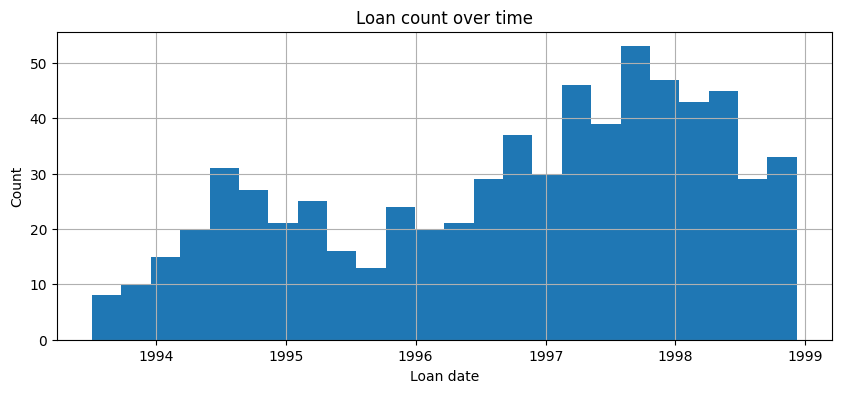

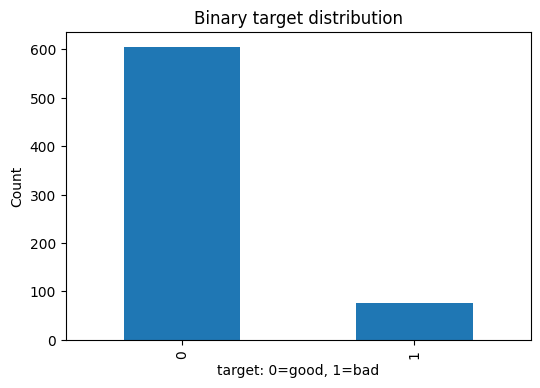

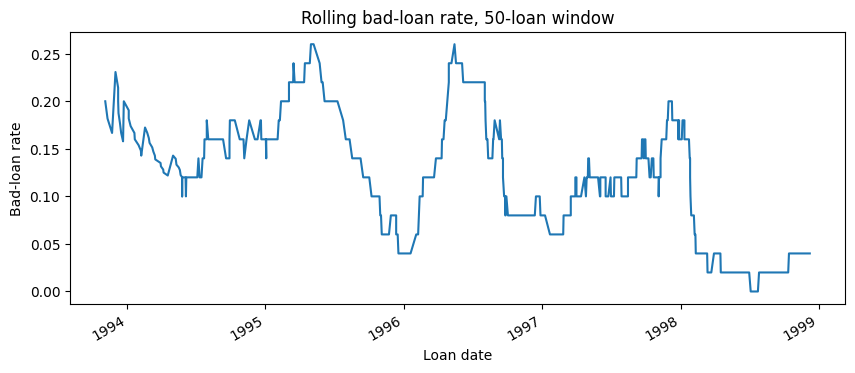

In [8]:
plot_df = meta.copy()
plot_df["target"] = y.values
plot_df = plot_df.sort_values("loan_date")

plt.figure(figsize=(10, 4))
plot_df["loan_date"].hist(bins=24)
plt.title("Loan count over time")
plt.xlabel("Loan date")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
y.value_counts().sort_index().plot(kind="bar")
plt.title("Binary target distribution")
plt.xlabel("target: 0=good, 1=bad")
plt.ylabel("Count")
plt.show()

rolling_bad_rate = plot_df.set_index("loan_date")["target"].rolling(window=50, min_periods=10).mean()

plt.figure(figsize=(10, 4))
rolling_bad_rate.plot()
plt.title("Rolling bad-loan rate, 50-loan window")
plt.xlabel("Loan date")
plt.ylabel("Bad-loan rate")
plt.show()

## 8. Temporal train/test split

For a banking dataset, a temporal split is more realistic than random train/test splitting. Here, earlier loans are used for training and later loans are used for testing.


In [9]:
X_train, X_test, y_train, y_test, meta_train, meta_test = temporal_train_test_split(X, y, meta, test_size=0.20)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train dates:", meta_train["loan_date"].min(), "to", meta_train["loan_date"].max())
print("Test dates:", meta_test["loan_date"].min(), "to", meta_test["loan_date"].max())

print("\nTrain target distribution:")
display(y_train.value_counts(normalize=False).rename_axis("target").reset_index(name="count"))
display(y_train.value_counts(normalize=True).rename("share").to_frame())

print("\nTest target distribution:")
display(y_test.value_counts(normalize=False).rename_axis("target").reset_index(name="count"))
display(y_test.value_counts(normalize=True).rename("share").to_frame())

Train shape: (541, 96)
Test shape: (141, 96)
Train dates: 1993-07-05 00:00:00 to 1998-01-23 00:00:00
Test dates: 1998-01-25 00:00:00 to 1998-12-08 00:00:00

Train target distribution:


,target,count
0,0,468
1,1,73


,share
target,
0,0.865065
1,0.134935



Test target distribution:


,target,count
0,0,138
1,1,3


,share
target,
0,0.978723
1,0.021277


## 9. Train and benchmark several models

The preprocessing is inside each sklearn pipeline:

- numeric imputation
- optional winsorization/scaling for logistic regression
- categorical imputation
- one-hot encoding
- classifier

Because bad loans are typically the minority class, focus on:

- ROC-AUC
- average precision / PR-AUC
- balanced accuracy
- recall for bad loans


In [10]:
model_names = ["logistic", "random_forest", "hist_gradient_boosting"]

fitted_models = {}
benchmark_rows = []

for model_name in model_names:
    print(f"\nTraining {model_name}...")
    clf = make_model_pipeline(model_name, random_state=config.random_state)
    clf.fit(X_train, y_train)
    fitted_models[model_name] = clf

    results = evaluate_binary_classifier(clf, X_test, y_test, threshold=0.50)
    benchmark_rows.append(
        {
            "model": model_name,
            "threshold": results["threshold"],
            "roc_auc": results.get("roc_auc", np.nan),
            "average_precision": results["average_precision"],
            "balanced_accuracy": results["balanced_accuracy"],
        }
    )

    print(results["classification_report"])
    print("Confusion matrix:\n", results["confusion_matrix"])
    print("ROC-AUC:", results.get("roc_auc"))
    print("Average precision:", results["average_precision"])

benchmark_df = pd.DataFrame(benchmark_rows).sort_values("average_precision", ascending=False)
display(benchmark_df)

best_model_name = benchmark_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
print("Best model by average precision:", best_model_name)


Training logistic...
              precision    recall  f1-score   support

           0     1.0000    0.8986    0.9466       138
           1     0.1765    1.0000    0.3000         3

    accuracy                         0.9007       141
   macro avg     0.5882    0.9493    0.6233       141
weighted avg     0.9825    0.9007    0.9328       141

Confusion matrix:
 [[124  14]
 [  0   3]]
ROC-AUC: 0.9927536231884058
Average precision: 0.8333333333333333

Training random_forest...
              precision    recall  f1-score   support

           0     0.9924    0.9493    0.9704       138
           1     0.2222    0.6667    0.3333         3

    accuracy                         0.9433       141
   macro avg     0.6073    0.8080    0.6519       141
weighted avg     0.9760    0.9433    0.9568       141

Confusion matrix:
 [[131   7]
 [  1   2]]
ROC-AUC: 0.9782608695652174
Average precision: 0.6

Training hist_gradient_boosting...
              precision    recall  f1-score   support

     

,model,threshold,roc_auc,average_precision,balanced_accuracy
2,hist_gradient_boosting,0.5,1.000000,1.000000,0.978261
0,logistic,0.5,0.992754,0.833333,0.949275
1,random_forest,0.5,0.978261,0.600000,0.807971


Best model by average precision: hist_gradient_boosting


## 10. Threshold tuning

Credit-risk classification is often not about the default threshold of `0.50`.

Lowering the threshold usually catches more bad loans but also rejects more good loans. The table below compares operating thresholds.


,threshold,tp,fp,tn,fn,precision_bad,recall_bad,false_positive_rate
0,0.10,3,13,125,0,0.187500,1.0,0.094203
1,0.15,3,12,126,0,0.200000,1.0,0.086957
2,0.20,3,9,129,0,0.250000,1.0,0.065217
3,0.25,3,7,131,0,0.300000,1.0,0.050725
4,0.30,3,7,131,0,0.300000,1.0,0.050725
5,0.35,3,7,131,0,0.300000,1.0,0.050725
6,0.40,3,7,131,0,0.300000,1.0,0.050725
7,0.45,3,7,131,0,0.300000,1.0,0.050725
8,0.50,3,6,132,0,0.333333,1.0,0.043478
9,0.55,3,6,132,0,0.333333,1.0,0.043478


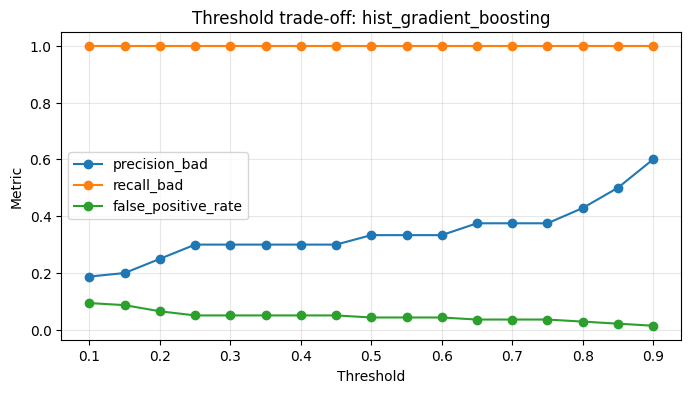

Chosen threshold: 0.35
              precision    recall  f1-score   support

           0     1.0000    0.9493    0.9740       138
           1     0.3000    1.0000    0.4615         3

    accuracy                         0.9504       141
   macro avg     0.6500    0.9746    0.7178       141
weighted avg     0.9851    0.9504    0.9631       141

Confusion matrix:
 [[131   7]
 [  0   3]]


In [11]:
best_proba = best_model.predict_proba(X_test)[:, 1]
thr = threshold_table(y_test, best_proba)

display(thr)

plt.figure(figsize=(8, 4))
plt.plot(thr["threshold"], thr["precision_bad"], marker="o", label="precision_bad")
plt.plot(thr["threshold"], thr["recall_bad"], marker="o", label="recall_bad")
plt.plot(
    thr["threshold"],
    thr["false_positive_rate"],
    marker="o",
    label="false_positive_rate",
)
plt.title(f"Threshold trade-off: {best_model_name}")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Choose an operating threshold. Adjust this depending on your business preference.
chosen_threshold = 0.35
chosen_results = evaluate_binary_classifier(best_model, X_test, y_test, threshold=chosen_threshold)
print("Chosen threshold:", chosen_threshold)
print(chosen_results["classification_report"])
print("Confusion matrix:\n", chosen_results["confusion_matrix"])

## 11. Feature importance

For tree models, we can inspect impurity-based feature importance. For logistic regression, we can inspect coefficients.

Interpret feature importance cautiously because one-hot encoded categories can split importance across many generated columns.


Random forest feature importance:


,feature,importance
0,num__tx_31_90d_balance_min,0.071657
1,num__tx_1_30d_balance_min,0.039035
2,num__tx_1_30d_balance_mean,0.035372
3,num__hist_balance_min,0.034136
4,num__tx_1_30d_bank_transfer_rate,0.033990
5,num__hist_net_cashflow_sum,0.033512
6,num__hist_last_balance,0.033354
7,num__hist_balance_change,0.033040
8,num__hist_bank_transfer_rate,0.032417
9,num__tx_91_180d_balance_min,0.032385


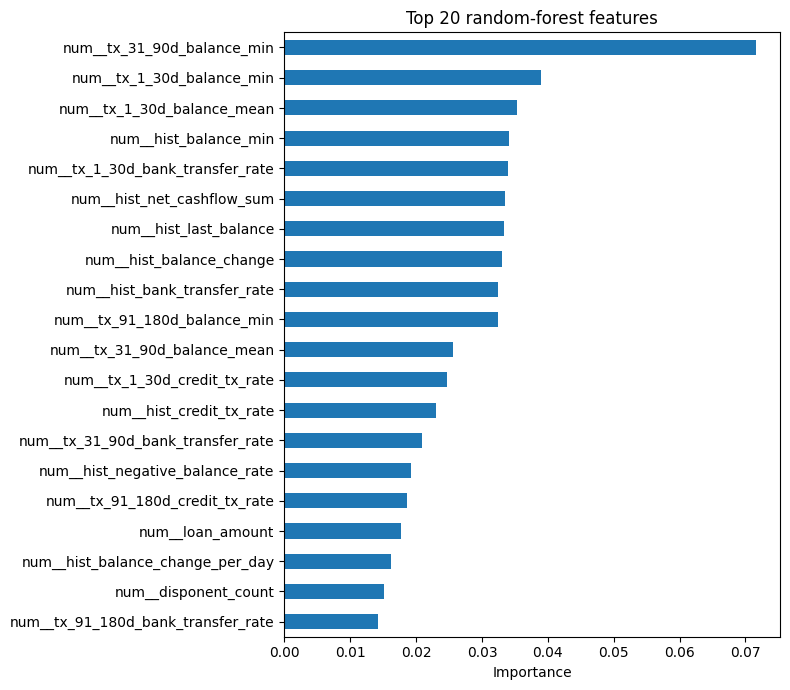

Logistic-regression largest absolute coefficients:


,feature,coefficient,abs_coefficient
0,num__tx_31_90d_cash_deposit_rate,-1.891931,1.891931
1,num__tx_31_90d_balance_min,-1.706391,1.706391
2,num__tx_1_30d_bank_transfer_rate,-1.578260,1.578260
3,num__account_district_average_salary,-1.216583,1.216583
4,num__tx_1_30d_credit_tx_rate,1.196974,1.196974
5,num__disponent_count,-1.103768,1.103768
6,num__client_count,-1.103768,1.103768
7,num__tx_31_90d_credit_tx_rate,1.092108,1.092108
8,num__tx_1_30d_cash_withdrawal_rate,1.040965,1.040965
9,num__account_district_unemployment_rate96,-0.974860,0.974860


In [12]:
# Random forest feature importance, if fitted.
if "random_forest" in fitted_models:
    rf = fitted_models["random_forest"]
    feature_names = get_feature_names(rf)
    importances = rf.named_steps["model"].feature_importances_
    rf_importance = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    print("Random forest feature importance:")
    display(rf_importance.head(30))

    plt.figure(figsize=(8, 7))
    rf_importance.head(20).sort_values("importance").plot(kind="barh", x="feature", y="importance", legend=False, ax=plt.gca())
    plt.title("Top 20 random-forest features")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

# Logistic-regression coefficients, if fitted.
if "logistic" in fitted_models:
    logit = fitted_models["logistic"]
    feature_names = get_feature_names(logit)
    coefs = logit.named_steps["model"].coef_.ravel()
    coef_df = (
        pd.DataFrame({"feature": feature_names, "coefficient": coefs})
        .assign(abs_coefficient=lambda d: d["coefficient"].abs())
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )
    print("Logistic-regression largest absolute coefficients:")
    display(coef_df.head(30))